# 表格展示与结果导出

学习目标：为同一张表选择文本、HTML 和样式展示，检查格式化没有改变数据，并用简单图形观察数值分布。

前置知识：DataFrame、缺失值、Python 格式化字符串、函数与文件操作。

运行环境：Python 3.12、pandas 3.0；示例按 pandas 3.0.6、Jinja2 3.1.6 编写，选学绘图使用 Matplotlib 3.11.2。

环境准备：[环境配置与运行](README.md)。

工作目录：本 Notebook 所在目录；重启内核后从上到下运行。

本章使用自制测量表，温度单位为摄氏度、合格率取值为 0 至 1。HTML 导出使用临时目录；需要在浏览器查看文件时，在清理单元之前打开。后续沿用 pd 和本章定义的 report。

## 1 先生成一份可读的文本表

to_string 将表格转换成便于阅读的文本。用 formatters 为不同列指定格式，na_rep 统一显示缺失，index=False 隐藏本次不需要展示的行标签。

本例要求温度保留一位小数、合格率显示百分比。格式化服务于阅读，底层仍保存原始数值，便于继续计算。

In [1]:
import pandas as pd

report = pd.DataFrame({"站点": ["北区", "南区", "东区"],
                       "温度_C": [21.256, 19.843, None],
                       "合格率": [0.9567, 0.8123, 0.99]})
original = report.copy()
text_report = report.to_string(index=False, na_rep="缺测", formatters={
    "温度_C": "{:.1f}".format, "合格率": "{:.1%}".format})
print(text_report)  # 温度显示 21.3、19.8、缺测；合格率显示 95.7%、81.2%、99.0%。
print(report.loc[0, "温度_C"])  # 21.256，原始精度仍在。
pd.testing.assert_frame_equal(report, original, check_exact=True)

站点 温度_C   合格率
北区 21.3 95.7%
南区 19.8 81.2%
东区   缺测 99.0%
21.256


## 2 在局部范围调整显示选项

display.max_rows 控制普通表格表示的最大行数，超过后可能截断；display.min_rows 控制截断时展示多少行。display.precision 调整数值展示精度，不修改存储精度。

option_context 在 with 块内临时设置选项，离开时恢复原值。示例使用完整选项名，避免缩写同时匹配多个选项。

In [2]:
long_table = pd.DataFrame({"reading": [1.23456 + i for i in range(8)]})
old_precision = pd.get_option("display.precision")
with pd.option_context("display.max_rows", 4, "display.min_rows", 4, "display.precision", 2):
    print(long_table)  # 显示首尾各两行，中间省略；底部仍说明总共 8 行。
print(pd.get_option("display.precision") == old_precision)  # True，恢复此前设置。
print(long_table.shape, long_table.loc[0, "reading"])  # (8, 1)、1.23456；没有删行或舍入数据。

    reading
0      1.23
1      2.23
..      ...
6      7.23
7      8.23

[8 rows x 1 columns]
True
(8, 1) 1.23456


### 2.1 选择列宽与完整输出

display.max_columns、display.max_colwidth 和 display.width 分别影响列数、单个文本的显示宽度和整体输出宽度。截断内容仍在原表中，不能把屏幕上可见的部分当成完整数据。

只需一次确定的文本导出时，直接给 to_string 指定 columns、max_rows、max_cols、max_colwidth 等参数更清楚。不要为查看一张大表就长期取消所有显示限制。

In [3]:
notes = pd.DataFrame({"站点": ["A", "B"], "说明": ["measurement awaiting review", "approved"]})
with pd.option_context("display.max_columns", 2, "display.max_colwidth", 12, "display.width", 60):
    print(notes)  # 较长说明被省略号截断。
print(notes.to_string(index=False, columns=["站点", "说明"], max_colwidth=None))
# 显式文本输出显示完整说明；原表两行均保留。

  站点           说明
0  A  measurem...
1  B     approved
站点                          说明
 A measurement awaiting review
 B                    approved


## 3 输出普通 HTML 表格

to_html 生成 HTML 表格文本；不传文件时返回字符串，传文件路径时写入文件。它适合基本的表格导出，参数 index、na_rep 和 float_format 决定具体展示。

escape=True 会转义单元格中的 HTML 特殊字符。像“带尖括号的备注”应显示为文本，而不是被浏览器解释成标签。这里保持转义，文件内容只来自自制输入。

In [4]:
plain_html = report.to_html(index=False, na_rep="缺测", float_format="{:.2f}".format,
                            escape=True, border=1)
print(plain_html.splitlines()[0])  # 开头是 table 标签。
print("21.26" in plain_html, "缺测" in plain_html)  # True True，已应用展示参数。
labels = pd.DataFrame({"备注": ["<待确认>", "A&B"]})
escaped_html = labels.to_html(index=False, escape=True)
print("&lt;待确认&gt;" in escaped_html, "A&amp;B" in escaped_html)  # True True。

<table border="1" class="dataframe">
True True
True True


## 4 用 Styler 分列格式化

DataFrame.style 返回 Styler，用于展示样式。format 按列设置显示文本；缺失通过 na_rep 表达，escape="html" 处理数据单元的特殊字符。它与直接修改数值或把整列转成字符串不同。

下面继续使用 report。列名是本章固定文本；若行列标签也来自外部文本，format_index 可分别按 index 与 columns 轴设置 HTML 转义。

In [5]:
styled = report.style.format({"温度_C": "{:.1f}", "合格率": "{:.1%}"},
                             na_rep="缺测", escape="html")
styled = styled.format_index(escape="html", axis="index")
styled = styled.format_index(escape="html", axis="columns")
formatted_html = styled.to_html(table_uuid="measurement")
print("95.7%" in formatted_html, "缺测" in formatted_html)  # True True。
print(report["合格率"].dtype, report.loc[0, "合格率"])  # float64、0.9567，仍可做数值计算。

True

 True
float64 0.9567


## 5 给需要关注的单元格加样式

Styler.map 把单个值交给函数，由函数返回 CSS 样式字符串；subset 限定作用列。返回空字符串表示不加样式。本例合格率均为非缺失数值，业务规则是低于 90% 时显示红色粗体。

highlight_null 单独突出缺测；颜色帮助定位，文字与数值仍保留，不能只靠颜色表达含义。此处的 CSS 是本节所演示的表格样式，不会改变 DataFrame 的值。

set_table_styles 为标题、表头和数据单元设置留白，并给表格安排适当宽度，避免长标题被挤成多行。

In [6]:
def highlight_low_rate(value):
    return "color: #b00020; font-weight: bold;" if value < 0.9 else ""


styled = styled.map(highlight_low_rate, subset=["合格率"])
styled = styled.highlight_null(color="#fff2cc", subset=["温度_C"])
styled = styled.set_caption("站点测量摘要：温度单位 °C；合格率低于 90% 用红色粗体显示")
styled = styled.hide(axis="index")
# 标题与单元格留出阅读空间；这些样式只改变导出的表格。
styled = styled.set_table_styles([
    {"selector": "", "props": [("width", "36rem"), ("max-width", "100%"),
                              ("border-collapse", "collapse"), ("font-family", "sans-serif")]},
    {"selector": "caption", "props": [("text-align", "left"), ("padding", "0.75rem 0"),
                                     ("line-height", "1.6")]},
    {"selector": "th, td", "props": [("padding", "0.6rem 1rem"), ("text-align", "left"),
                                    ("border-bottom", "1px solid #cbd5e1")]},
])
styled_html = styled.to_html(table_uuid="measurement", doctype_html=True, encoding="utf-8")
print("color: #b00020" in styled_html, "background-color: #fff2cc" in styled_html)  # True True。
print(report.shape, report.index.tolist())  # (3, 3)、[0, 1, 2]；隐藏索引没有删除它。
pd.testing.assert_frame_equal(report, original, check_exact=True)

True

 True
(3, 3) [0, 1, 2]


## 6 导出并打开 HTML

Styler.to_html 的 doctype_html=True 生成包含文档结构的 HTML；指定 UTF-8 便于正确显示中文。这里保留一个临时目录，文件在清理之前可反复查看。

运行后，将打印的 report.html 完整路径粘贴到浏览器地址栏。核对三行数据、中文标题、缺测标记与低合格率样式。这里只打开自制静态文件，不需要启动网络服务。

下面是上述自制报告的实际浏览器截图：南区合格率显示为红色粗体，东区缺测单元格使用浅黄色背景；文字和原始数值仍承担主要含义。浏览器字体可能因系统而不同。

![站点测量摘要的实际浏览器截图](image/25-styler-report.png)

In [7]:
from pathlib import Path
from tempfile import TemporaryDirectory

report_directory = TemporaryDirectory(prefix="pandas-report-")
report_path = Path(report_directory.name) / "report.html"
styled.to_html(report_path, table_uuid="measurement", doctype_html=True, encoding="utf-8")
print(report_path)  # 在清理单元执行前，可将此完整路径粘贴到浏览器打开。
print(report_path.read_text(encoding="utf-8") == styled_html)  # True，文件与刚才生成的 HTML 一致。

C:\Users\ZHUANG\AppData\Local\Temp\pandas-report-b87o11wb\report.html
True


### 6.1 格式导出不等于数据导出

HTML 报表服务于阅读，百分号、缺测文字和颜色不构成通用的数据类型约定。后续程序需要处理原数值时，应另行导出原始字段，并在读取时明确类型与缺失规则。

Styler 的不同输出格式并不完全共享规则：format 的 Python 显示格式和 hide 的隐藏规则不适用于 to_excel。需要 Excel 数字格式时应使用其支持的 number-format 规则，本章只展开 HTML。

In [8]:
print(report.to_csv(index=False, na_rep=""))
# CSV 中合格率仍是 0.9567 等原数值，而不是 95.7% 文本；温度保留 21.256。
print(report["合格率"].mean())  # 仍可求均值，约 0.9197；没有先变成百分数字符串。
pd.testing.assert_frame_equal(report, original, check_exact=True)

站点,温度_C,合格率
北区,21.256,0.9567
南区,19.843,0.8123
东区,,0.99

0.9196666666666667


## 7 清理临时报告

完成页面查看后调用 cleanup 删除临时目录及其中的报告。若此前已顺序运行整篇，文件会被自动清理；需要重新打开时重跑“导出并打开 HTML”的单元，查看后再运行本单元。

下面沿用 report_directory 和 report_path，只清理本章创建的临时资源。

In [9]:
report_directory.cleanup()
print(report_path.exists())  # False，临时报告已删除。

False


## 8 选学：折线图观察变化

pandas 的 plot 使用绘图后端，默认后端是 Matplotlib。本例显式选择 matplotlib，并用 plt.show 显示结果、plt.close 关闭图形，避免后续单元积累图形对象。

以下绘图是可选的数据检查。输入独立给出，elapsed_s 表示经过秒数，temperature_c 表示摄氏温度；轴标签用英文名称与单位，避免依赖额外中文字体。连线只表示按给定顺序连接的观测，不自动补出未观测时刻的事实。

(4, 2)


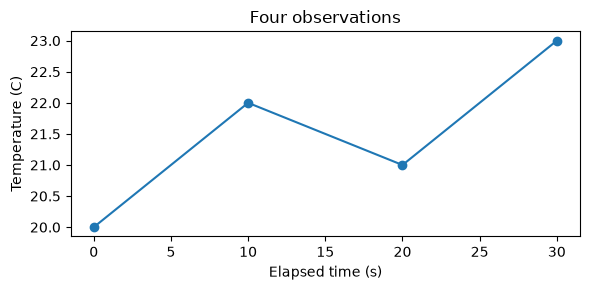

In [10]:
import matplotlib.pyplot as plt

measurements = pd.DataFrame({"elapsed_s": [0, 10, 20, 30], "temperature_c": [20, 22, 21, 23]})
axis = measurements.plot(x="elapsed_s", y="temperature_c", kind="line", marker="o",
                         backend="matplotlib", legend=False, figsize=(6, 3),
                         xlabel="Elapsed time (s)", ylabel="Temperature (C)", title="Four observations")
axis.figure.tight_layout()
print(measurements.shape)  # (4, 2)；图中四个点依次为 20、22、21、23 °C。
plt.show()
plt.close(axis.figure)

## 9 选学：直方图检查分布

hist 统计落入各区间的观测数。下面显式选择数值列并先去掉缺失，记录有效样本数；bins 指定区间边界。边界序列用于确定分箱，不能把柱高直接解释成每个具体数值的出现次数。

本例区间为 [0, 2)、[2, 4)、[4, 6]，最后一个区间包含最右端点。先手工数一数每个区间，再对照图中的柱高。

6 1
[2, 2, 2]


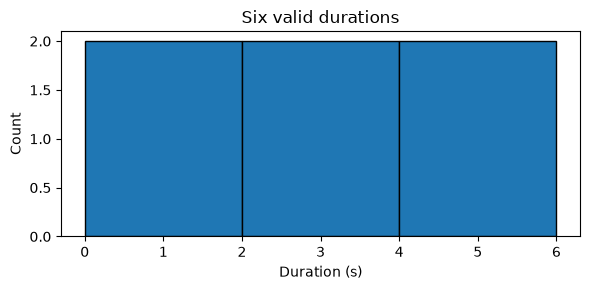

In [11]:
durations = pd.DataFrame({"duration_s": [1.0, 1.5, 2.0, 3.0, 4.0, 6.0, None]})
valid_durations = durations.dropna(subset=["duration_s"])
axes = valid_durations.hist(column="duration_s", bins=[0, 2, 4, 6], backend="matplotlib",
                            figsize=(6, 3), grid=False, edgecolor="black")
axis = axes[0, 0]
axis.set_xlabel("Duration (s)")
axis.set_ylabel("Count")
axis.set_title("Six valid durations")
axis.figure.tight_layout()
print(len(valid_durations), durations["duration_s"].isna().sum())  # 6 个有效值、1 个缺失。
print([int(bar.get_height()) for bar in axis.patches])  # [2, 2, 2]，总数为 6。
plt.show()
plt.close(axis.figure)

## 10 选学：箱线图与原始值

boxplot 用四分位数概括分布。箱体从第一四分位数 Q1 到第三四分位数 Q3，中线是中位数；四分位距 IQR 为 Q3−Q1。默认须线伸到距离箱体不超过 1.5×IQR 的最远观测，之外的点单独绘制。

图上单独标出的点不自动等于录入错误，仍需回到原始记录判断。下面不含缺失，样本很小，同时打印原值和四分位数帮助核对。

[10, 11, 12, 13, 14, 30]
[11.25, 12.5, 13.75]


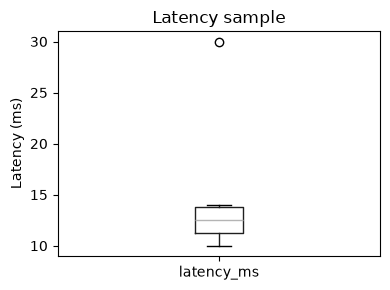

In [12]:
latencies = pd.DataFrame({"latency_ms": [10, 11, 12, 13, 14, 30]})
axis = latencies.boxplot(column="latency_ms", backend="matplotlib", figsize=(4, 3), grid=False)
axis.set_ylabel("Latency (ms)")
axis.set_title("Latency sample")
axis.figure.tight_layout()
print(latencies["latency_ms"].tolist())  # 六个原始值，30 ms 在图中单独标出。
print(latencies["latency_ms"].quantile([0.25, 0.5, 0.75]).tolist())  # [11.25, 12.5, 13.75]。
plt.show()
plt.close(axis.figure)

## 本章小结

（1）显示精度、百分比文本和缺测标记服务于阅读，不等于改变底层值；用副本比较确认展示前后数据一致。

（2）option_context 限定选项生效范围；截断表示没有删掉原表数据，完整文本输出可直接指定 to_string 参数。

（3）to_html 输出基本表格，Styler.format、map 与 highlight_null 分别处理文本、条件样式和缺失样式；导出后应打开页面核对。

（4）选学绘图要说明字段、单位、有效样本与分箱规则；图形用于发现值得检查的现象，不能代替原始数据与业务判断。

## 练习

（1）把下表输出为不含行索引的文本，金额保留两位小数，缺失显示“待补”。检查原表的 12.345 仍然存在，解释为何显示两位小数不等于财务舍入规则。

In [13]:
prices = pd.DataFrame({"item": ["A", "B"], "price_yuan": [12.345, None]})
# 在此用 to_string 生成文本，并比较展示前后数据。
# 检查两行均在，缺失显示“待补”，底层 price_yuan 没有被改写。

（2）先预测两个 print 的输出，再运行。若要求临时查看最多 20 行并恢复原设置，应该采用什么写法？解释为何全局 set_option 后忘记恢复可能影响后续阅读。

In [14]:
sample = pd.DataFrame({"value": [0.123456]})
with pd.option_context("display.precision", 2):
    print(sample)
print(sample.loc[0, "value"])
# 先记录“显示值”和“存储值”的预测，再增加临时行数选项。

   value
0   0.12
0.123456


（3）把备注作为普通文本导出 HTML，并让 score 缺失显示“未评分”。任务后来要求低于 60 分的成绩变红，选择 to_html 还是 Styler，说明理由；处理好缺失值，检查原值与类型不变。

In [15]:
scores = pd.DataFrame({"note": ["<待确认>", "A&B", "复核"], "score": [59.5, None, 80.0]})
# 在此设置显示格式、HTML 转义与条件样式；不把备注当作 HTML 标签。
# 检查：只有 59.5 对应条件样式，缺失仍是缺失；导出后打开实际页面。

（4）选学：将下表画成直方图，区间边界使用 0、5、10，说明缺失样本是否参与统计。若任务改为观察每次测量随时间变化，仅凭直方图是否足够？说明应补充的字段与图形。

In [16]:
samples = pd.DataFrame({"duration_s": [1, 4, 5, 8, 10, None]})
# 在此先说明缺失处理，再绘图；两箱计数应为 2、3，总计 5。
# 轴标签注明秒和频数；若需要时间变化，还要有观测时间或明确顺序。

### 重点练习提示（第 3 题）

提示一：把内容转义、缺失显示与条件样式分成三个独立要求。

提示二：使用 Styler.format 的 escape 与 na_rep，再对 score 子集 map；样式函数先处理缺失。

### 参考解析（第 3 题）

选择 Styler：format 设置 escape="html"、na_rep="未评分"，score 可显示一位小数；map 仅作用于 score，缺失返回空样式，非缺失且小于 60 才返回红色样式。实际页面应显示文本 &lt;待确认&gt;、A&B、复核，59.5 为红色，缺失位置显示未评分，80.0 不变红。HTML 中备注应被转义，不能只靠字符串存在就断言页面正确；导出后实际打开检查。最后用 assert_frame_equal 比较导出前后的 scores 与副本，确认形状、索引、dtype、数值和缺失均未变化。

## 参考与引用来源

在线文档可能随发布更新；固定版本对照见下表 pandas v3.0.6 文档或 API 源码。API 参数与异常仍须结合所列页面的具体定位阅读。

| 网站 | 本章参考内容与定位 |
| --- | --- |
| pandas 官方在线文档（课程基线 3.0.6） | [Options and settings](https://pandas.pydata.org/docs/user_guide/options.html) 的 Getting and setting options、Frequently used options；[to_string](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_string.html) 的 formatters、na_rep、列宽与截断；[to_html](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.to_html.html) 的转义与输出；[Styler.format](https://pandas.pydata.org/docs/reference/api/pandas.io.formats.style.Styler.format.html)、[format_index](https://pandas.pydata.org/docs/reference/api/pandas.io.formats.style.Styler.format_index.html) 的显示与 HTML 转义；Styler.format 的 Warning 明确 Python 格式不用于 to_excel；[map](https://pandas.pydata.org/docs/reference/api/pandas.io.formats.style.Styler.map.html)、[highlight_null](https://pandas.pydata.org/docs/reference/api/pandas.io.formats.style.Styler.highlight_null.html)、[hide](https://pandas.pydata.org/docs/reference/api/pandas.io.formats.style.Styler.hide.html)、[to_html](https://pandas.pydata.org/docs/reference/api/pandas.io.formats.style.Styler.to_html.html) 的样式、隐藏与导出条件，其中 hide 的 Warning 明确 Excel 导出不保留隐藏规则；[set_table_styles](https://pandas.pydata.org/docs/reference/api/pandas.io.formats.style.Styler.set_table_styles.html) 的 selector、props 与表格 CSS（页面标识 3.0.5，已对照本机 3.0.6 官方发行包同名方法）；[Table Visualization](https://pandas.pydata.org/docs/user_guide/style.html) 的格式与数据区别；[plot](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.plot.html)、[hist](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.hist.html)、[boxplot](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.boxplot.html) 的后端、轴与箱线定义；[Chart visualization](https://pandas.pydata.org/docs/user_guide/visualization.html) 的 Basic plotting、Histograms、Box plots。 |
| Matplotlib 官方文档（3.11.2） | [pyplot.show](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.show.html) 与 [close](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.close.html) 的显示和资源释放；[hist](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.hist.html) 的 bins 端点规则与频数；[Axes.set_xlabel](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_xlabel.html) 和 [set_ylabel](https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.set_ylabel.html) 的轴标签。 |
| Python 官方文档（3.12） | [TemporaryDirectory](https://docs.python.org/3.12/library/tempfile.html#tempfile.TemporaryDirectory) 的生命周期与 cleanup；[Path.read_text](https://docs.python.org/3.12/library/pathlib.html#pathlib.Path.read_text) 的编码读取；[Format Specification Mini-Language](https://docs.python.org/3.12/library/string.html#format-specification-mini-language) 的精度与百分比格式。 |
| GitHub 官方项目（版本化来源） | pandas v3.0.6 文档源码：[options](https://github.com/pandas-dev/pandas/blob/v3.0.6/doc/source/user_guide/options.rst)、[style](https://github.com/pandas-dev/pandas/blob/v3.0.6/doc/source/user_guide/style.ipynb)、[visualization](https://github.com/pandas-dev/pandas/blob/v3.0.6/doc/source/user_guide/visualization.rst)；对应上列同名指南或发布说明的小节，作为固定版本对照。 |